In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
from matplotlib import rcParams
rcParams['figure.figsize'] = 12, 10

In [74]:
np.random.seed(10)


in_simple_x =  np.pi / 180 * np.random.uniform(0, 400, 200)
out_samples = np.pi / 180 * np.random.uniform(0, 400, 80)

in_sample_x = np.sort(in_simple_x)
out_sample_x = np.sort(out_samples)

In [75]:
in_sample_y = 1 - np.cos(in_sample_x) + in_sample_x +np.random.normal(0, 0.15, in_sample_x.shape[0])
out_sample_y = 1 - np.cos(out_sample_x) + out_sample_x +np.random.normal(0, 0.15, out_sample_x.shape[0])

data_in = pd.DataFrame(np.column_stack((in_sample_x, in_sample_y)), columns=['x', 'y'])
data_out = pd.DataFrame(np.column_stack((out_sample_x, out_sample_y)), columns=['x', 'y'])

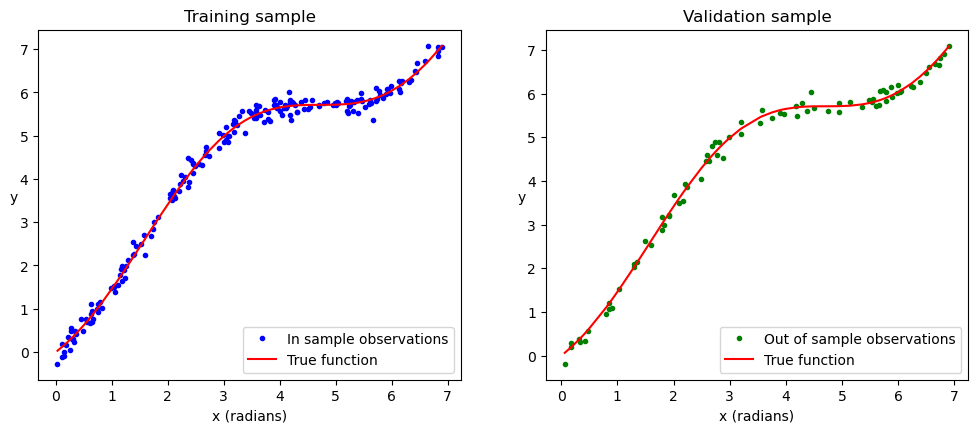

In [76]:
plt.figure(1)
plt.subplot(221)
plt.plot(data_in['x'], data_in['y'], '.', color='blue', label="In sample observations")
plt.plot(data_in['x'], 1 - np.cos(in_sample_x) + in_sample_x, color='red', label="True function")
plt.legend(loc = "lower right")
plt.title('Training sample')
plt.xlabel('x (radians)')
plt.ylabel('y', rotation=0)
plt.subplot(222)
plt.plot(data_out['x'], data_out['y'], '.', color='green', label="Out of sample observations")
plt.plot(data_out['x'], 1 - np.cos(out_sample_x) + out_sample_x, color='red', label="True function")
plt.title('Validation sample')
plt.xlabel('x (radians)')
plt.ylabel('y', rotation=0)
plt.legend(loc = "lower right")

In [77]:
for i in range(2, 40):
    colname = 'x_%d' % i
    data_in[colname] = data_in['x'] ** i
    data_out[colname] = data_out['x'] ** i

display(data_in.head())

,x,y,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,...,x_30,x_31,x_32,x_33,x_34,x_35,x_36,x_37,x_38,x_39
0,0.027564,-0.274714,0.000760,0.000021,5.772650e-07,1.591179e-08,4.385941e-10,1.208945e-11,3.332348e-13,9.185318e-15,...,1.622983e-47,4.473606e-49,1.233109e-50,3.398955e-52,9.368912e-54,2.582456e-55,7.118308e-57,1.962097e-58,5.408345e-60,1.490761e-61
1,0.102171,0.188467,0.010439,0.001067,1.089696e-04,1.113350e-05,1.137518e-06,1.162210e-07,1.187438e-08,1.213214e-09,...,1.904546e-30,1.945888e-31,1.988127e-32,2.031283e-33,2.075377e-34,2.120427e-35,2.166455e-36,2.213482e-37,2.261530e-38,2.310621e-39
2,0.103743,-0.107226,0.010763,0.001117,1.158317e-04,1.201668e-05,1.246641e-06,1.293297e-07,1.341699e-08,1.391913e-09,...,3.010972e-30,3.123658e-31,3.240563e-32,3.361842e-33,3.487660e-34,3.618188e-35,3.753600e-36,3.894080e-37,4.039818e-38,4.191009e-39
3,0.144876,-0.085975,0.020989,0.003041,4.405397e-04,6.382360e-05,9.246504e-06,1.339596e-06,1.940752e-07,2.811683e-08,...,6.759082e-26,9.792284e-27,1.418666e-27,2.055306e-28,2.977644e-29,4.313890e-30,6.249788e-31,9.054439e-32,1.311770e-32,1.900440e-33
4,0.147761,0.007672,0.021833,0.003226,4.766924e-04,7.043650e-05,1.040776e-05,1.537860e-06,2.272356e-07,3.357654e-08,...,1.221200e-25,1.804456e-26,2.666280e-27,3.939719e-28,5.821365e-29,8.601702e-30,1.270995e-30,1.878034e-31,2.775001e-32,4.100366e-33


In [78]:
from sklearn.linear_model import LinearRegression

def linear_regression(data1, data2, power, models_to_plot):
    predictors = ['x']
    if power >= 2:
        predictors.extend(['x_%d' % i for i in range(2, power + 1)])

    
    linreg = LinearRegression()
    linreg.fit(data1[predictors], data1['y'])
    y_pred = linreg.predict(data1[predictors])
    y_pred_out = linreg.predict(data2[predictors])

    if power in models_to_plot:
        plt.subplot(models_to_plot[power])
        plt.tight_layout()
        plt.plot(data1['x'], y_pred, color='red')
        plt.plot(data1['x'], data1['y'],'.', color ='blue' )
        plt.title('Training sample: Plot for power: %d'%power)

        plt.subplot(models_to_plot[power] + 1)
        plt.tight_layout()
        plt.plot(data1['x'], y_pred, color = 'red')
        plt.plot(data2['x'], data2['y'], '.', color = 'green')
        plt.title('Validation sample: Plot for power: %d' % power)

    rss = sum((y_pred - data1['y']) ** 2) / len(y_pred)
    cvrss = sum((y_pred_out - data2['y']) ** 2) / len(y_pred_out)
    ret = [rss, cvrss]
    ret.extend([linreg.intercept_])
    ret.extend(linreg.coef_)
    return ret


In [79]:
col = ['rss', 'cross-rss','intercept'] + ['coef_x_%d' % i for i in range(1,40)]
ind = ['model_pow_%d' % i for i in range(1,40)]
coef_matrix_simple = pd.DataFrame(index=ind, columns=col)

,rss,cross-rss,intercept,coef_x_1,coef_x_2,coef_x_3,coef_x_4,coef_x_5,coef_x_6,coef_x_7,...,coef_x_30,coef_x_31,coef_x_32,coef_x_33,coef_x_34,coef_x_35,coef_x_36,coef_x_37,coef_x_38,coef_x_39
model_pow_1,0.571643,0.570591,1.047624,0.979189,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_2,0.100858,0.108813,-0.374976,2.283665,-0.197841,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_3,0.077862,0.071974,-0.748344,2.978671,-0.456516,0.025549,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_4,0.021319,0.020088,-0.061243,0.932168,0.883981,-0.278721,0.022242,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_5,0.020755,0.018351,0.021805,0.577146,1.24074,-0.415677,0.044467,-0.001284,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_6,0.019091,0.018112,-0.13759,1.502078,-0.094987,0.361054,-0.167661,0.025911,-0.00132,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_7,0.019081,0.017997,-0.152179,1.608969,-0.297865,0.521504,-0.230823,0.038978,-0.002679,0.000056,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_8,0.018704,0.01928,-0.253745,2.528492,-2.550175,2.888475,-1.513539,0.425891,-0.068234,0.005888,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_9,0.018694,0.01905,-0.271865,2.72858,-3.166422,3.715192,-2.097013,0.663032,-0.125676,0.014071,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_10,0.018494,0.019563,-0.366125,3.957792,-7.728899,11.185763,-8.644207,4.051405,-1.211251,0.231697,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


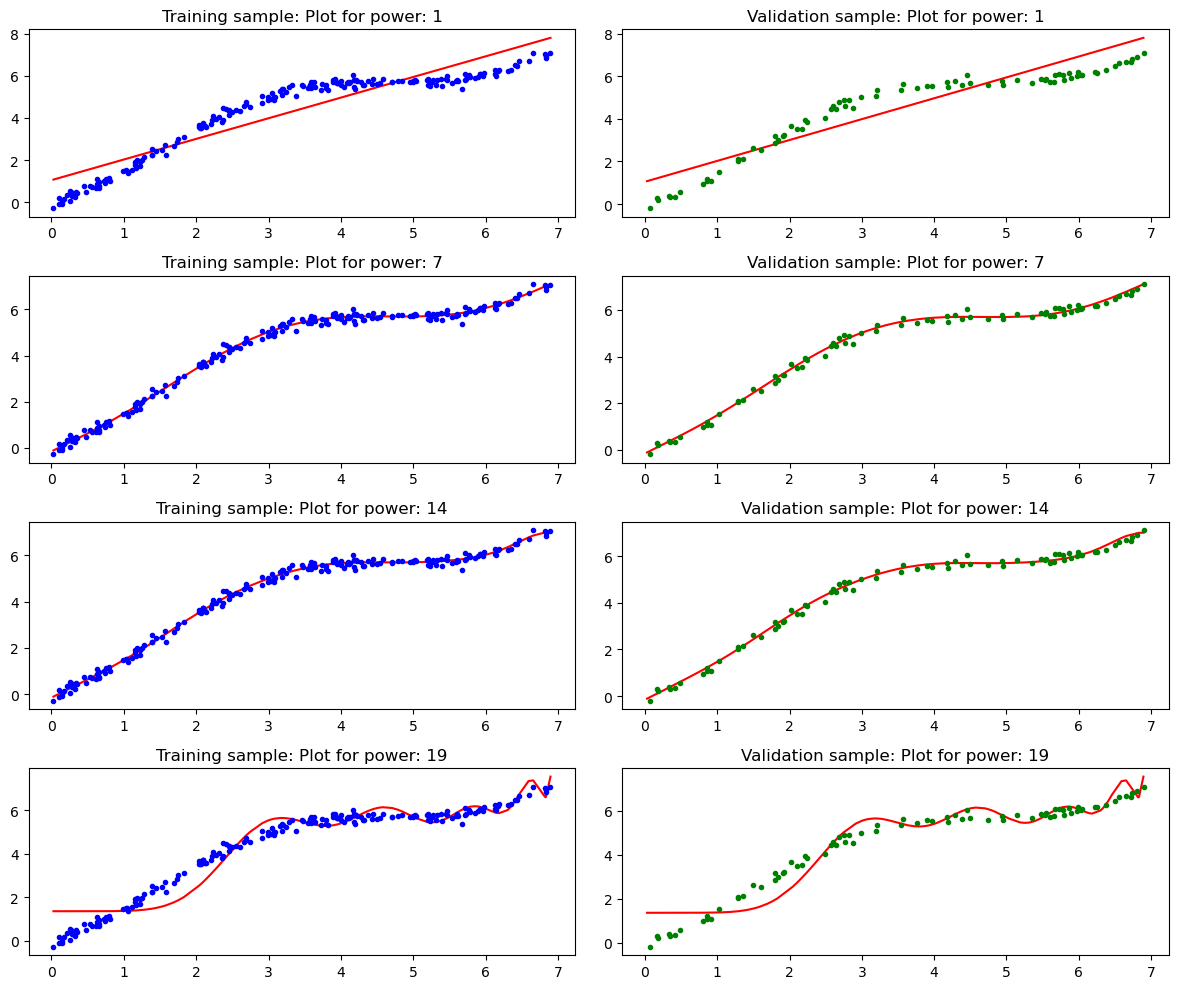

In [80]:
models_to_plot = {1:421, 7:423, 14:425, 19:427}

# Iterate through all powers and assimilate results
for i in range(1,40):
    coef_matrix_simple.iloc[i-1, 0:i+3] = linear_regression(data_in, data_out, power=i, models_to_plot=models_to_plot)
coef_matrix_simple

Text(0, 0.5, 'MSE')

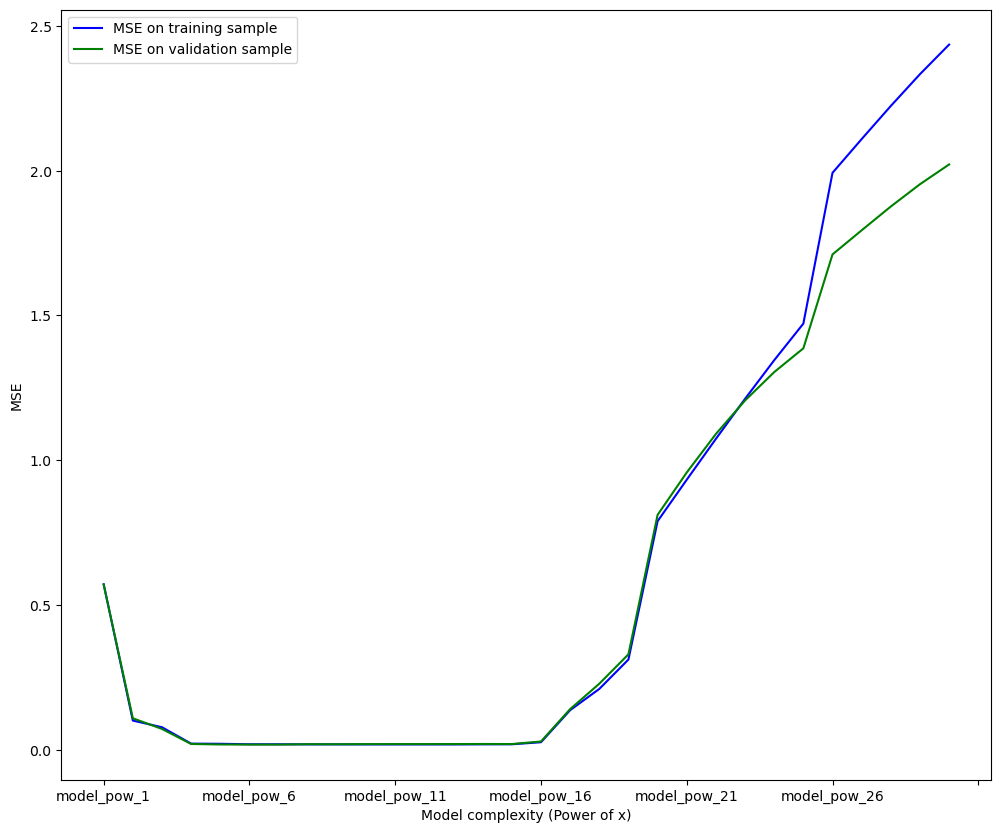

In [81]:
ax = coef_matrix_simple['rss'][0:30].plot(color='blue', label='MSE on training sample')
coef_matrix_simple['cross-rss'][0:30].plot(ax=ax, color='green',  label='MSE on validation sample')
ax.legend( loc='upper left')
ax.set_xlabel("Model complexity (Power of x)")
ax.set_ylabel("MSE")